# COVID-19 New Cases Prediction Using Deep Learning


In [1]:
# Import required libraries
import os
import random

# The warnings library is used to hide non-critical warning messages.
import warnings
warnings.filterwarnings("ignore")

# NumPy is used for numerical arrays and reshaping sequence data.
import numpy as np
import pandas as pd

# Data Visualisation
import matplotlib.pyplot as plt

import joblib

# Scikit-learn tools are used for scaling and regression evaluation metrics.
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# TensorFlow and Keras are used to build and train the deep learning models.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


# These fixed seed values make the notebook results more stable between runs.
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)


pd.set_option("display.max_columns", 120)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


* Load the COVID-19 dataset

In [2]:
DATA_PATH = "owid-covid-data (2).csv"

In [3]:
raw_df = pd.read_csv(DATA_PATH)

In [4]:
raw_df["date"] = pd.to_datetime(raw_df["date"], errors="coerce")

In [5]:
print("Dataset path used:", DATA_PATH)
print("Dataset shape:", raw_df.shape)
print("Start date:", raw_df["date"].min())
print("End date:", raw_df["date"].max())

Dataset path used: owid-covid-data (2).csv
Dataset shape: (429435, 67)
Start date: 2020-01-01 00:00:00
End date: 2024-08-14 00:00:00


In [6]:
# Display the first five rows to understand the raw structure.
raw_df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,new_deaths_per_million,new_deaths_smoothed_per_million,reproduction_rate,icu_patients,icu_patients_per_million,hosp_patients,hosp_patients_per_million,weekly_icu_admissions,weekly_icu_admissions_per_million,weekly_hosp_admissions,weekly_hosp_admissions_per_million,total_tests,new_tests,total_tests_per_thousand,new_tests_per_thousand,new_tests_smoothed,new_tests_smoothed_per_thousand,positive_rate,tests_per_case,tests_units,total_vaccinations,people_vaccinated,people_fully_vaccinated,total_boosters,new_vaccinations,new_vaccinations_smoothed,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,new_vaccinations_smoothed_per_million,new_people_vaccinated_smoothed,new_people_vaccinated_smoothed_per_hundred,stringency_index,population_density,median_age,aged_65_older,aged_70_older,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,54.42,18.6,2.58,1.34,1803.99,NaN,597.03,9.59,NaN,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,54.42,18.6,2.58,1.34,1803.99,NaN,597.03,9.59,NaN,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,54.42,18.6,2.58,1.34,1803.99,NaN,597.03,9.59,NaN,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,54.42,18.6,2.58,1.34,1803.99,NaN,597.03,9.59,NaN,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,54.42,18.6,2.58,1.34,1803.99,NaN,597.03,9.59,NaN,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [7]:
# This cell summarises column names, data types, and non-null values.
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   iso_code                                    429435 non-null  object        
 1   continent                                   402910 non-null  object        
 2   location                                    429435 non-null  object        
 3   date                                        429435 non-null  datetime64[ns]
 4   total_cases                                 411804 non-null  float64       
 5   new_cases                                   410159 non-null  float64       
 6   new_cases_smoothed                          408929 non-null  float64       
 7   total_deaths                                411804 non-null  float64       
 8   new_deaths                                  410608 non-null  float64      

* Missing value analysis

In [8]:
# Missing percentages are calculated to identify columns that are weak for modelling.
missing_summary = raw_df.isna().mean().mul(100).sort_values(ascending=False).reset_index()

# Clear column names are assigned for readability.
missing_summary.columns = ["column", "missing_percentage"]

# The top missing columns are displayed for data-quality reporting.
missing_summary.head(20)

,column,missing_percentage
0,weekly_icu_admissions,97.440125
1,weekly_icu_admissions_per_million,97.440125
2,excess_mortality,96.877059
3,excess_mortality_cumulative_absolute,96.877059
4,excess_mortality_cumulative,96.877059
5,excess_mortality_cumulative_per_million,96.877059
6,weekly_hosp_admissions,94.295528
7,weekly_hosp_admissions_per_million,94.295528
8,icu_patients_per_million,90.891287
9,icu_patients,90.891287


* Country-level filtering

In [9]:
country_level_df = raw_df.loc[raw_df["continent"].notna()].copy()

# This summary confirms the number of country-level rows and locations.
print("Country-level dataset shape:", country_level_df.shape)
print("Number of country-level locations:", country_level_df["location"].nunique())

Country-level dataset shape: (402910, 67)
Number of country-level locations: 243


In [10]:
# The first few unique locations are shown for a quick sanity check.
country_level_df[["continent", "location", "date"]].head()

,continent,location,date
0,Asia,Afghanistan,2020-01-05
1,Asia,Afghanistan,2020-01-06
2,Asia,Afghanistan,2020-01-07
3,Asia,Afghanistan,2020-01-08
4,Asia,Afghanistan,2020-01-09


## 2. Data Selection

* Select modelling country

In [11]:
# United Kingdom is selected
SELECTED_COUNTRY = "United Kingdom"

In [12]:
# The selected country is filtered from the country-level dataset.
country_df = country_level_df.loc[country_level_df["location"].eq(SELECTED_COUNTRY)].copy()

In [13]:
# The data is sorted by date because LSTM models require chronological order.
country_df = country_df.sort_values("date").reset_index(drop=True)

In [14]:
# Duplicate dates are merged by keeping the latest non-null values available for each date.
country_df = country_df.groupby("date", as_index=False).last()

In [15]:
# This output confirms the selected country time range.
print("Selected country:", SELECTED_COUNTRY)
print("Country data shape:", country_df.shape)
print("Country start date:", country_df["date"].min())
print("Country end date:", country_df["date"].max())

Selected country: United Kingdom
Country data shape: (1674, 67)
Country start date: 2020-01-05 00:00:00
Country end date: 2024-08-04 00:00:00


In [16]:
# Display the first five records for the selected country.
country_df.head()

,date,iso_code,continent,location,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,new_deaths_per_million,new_deaths_smoothed_per_million,reproduction_rate,icu_patients,icu_patients_per_million,hosp_patients,hosp_patients_per_million,weekly_icu_admissions,weekly_icu_admissions_per_million,weekly_hosp_admissions,weekly_hosp_admissions_per_million,total_tests,new_tests,total_tests_per_thousand,new_tests_per_thousand,new_tests_smoothed,new_tests_smoothed_per_thousand,positive_rate,tests_per_case,tests_units,total_vaccinations,people_vaccinated,people_fully_vaccinated,total_boosters,new_vaccinations,new_vaccinations_smoothed,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,new_vaccinations_smoothed_per_million,new_people_vaccinated_smoothed,new_people_vaccinated_smoothed_per_hundred,stringency_index,population_density,median_age,aged_65_older,aged_70_older,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,2020-01-05,GBR,Europe,United Kingdom,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,272.9,40.8,18.52,12.53,39753.24,0.2,122.14,4.28,20.0,24.7,NaN,2.54,81.32,0.93,67508936,71.9,0.53,0.53,1.07
1,2020-01-06,GBR,Europe,United Kingdom,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,272.9,40.8,18.52,12.53,39753.24,0.2,122.14,4.28,20.0,24.7,NaN,2.54,81.32,0.93,67508936,NaN,NaN,NaN,NaN
2,2020-01-07,GBR,Europe,United Kingdom,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,272.9,40.8,18.52,12.53,39753.24,0.2,122.14,4.28,20.0,24.7,NaN,2.54,81.32,0.93,67508936,NaN,NaN,NaN,NaN
3,2020-01-08,GBR,Europe,United Kingdom,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,272.9,40.8,18.52,12.53,39753.24,0.2,122.14,4.28,20.0,24.7,NaN,2.54,81.32,0.93,67508936,NaN,NaN,NaN,NaN
4,2020-01-09,GBR,Europe,United Kingdom,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,272.9,40.8,18.52,12.53,39753.24,0.2,122.14,4.28,20.0,24.7,NaN,2.54,81.32,0.93,67508936,NaN,NaN,NaN,NaN


* Select relevant modelling features

In [17]:
# These features represent cases, deaths, vaccination, testing, policy, transmission, and country context.
feature_columns = [
    "new_cases_smoothed",
    "new_deaths_smoothed",
    "total_cases_per_million",
    "total_deaths_per_million",
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred",
    "total_boosters_per_hundred",
    "positive_rate",
    "reproduction_rate",
    "stringency_index",
    "population_density",
    "median_age",
    "gdp_per_capita",
    "hospital_beds_per_thousand"
]

In [18]:
# A modelling DataFrame is created using only the selected date and feature columns.
model_df = country_df[["date"] + feature_columns].copy()

In [19]:
# Numeric conversion
model_df[feature_columns] = model_df[feature_columns].apply(pd.to_numeric, errors="coerce")

In [20]:
# Time-based interpolation fills internal gaps using nearby historical values.
model_df[feature_columns] = model_df[feature_columns].interpolate(method="linear", limit_direction="both")

# Forward fill and backward fill handle remaining edge missing values.
model_df[feature_columns] = model_df[feature_columns].ffill().bfill()

In [21]:
# Any remaining missing values are replaced with zero to avoid model training errors.
model_df[feature_columns] = model_df[feature_columns].fillna(0)

# Negative values are clipped to zero because negative case and death indicators are not meaningful for this target task.
model_df[feature_columns] = model_df[feature_columns].clip(lower=0)

In [22]:
# The target is the next-day smoothed new cases value.
model_df["target_next_day_cases"] = model_df["new_cases_smoothed"].shift(-1)

# The final row is removed because it does not have a known next-day target.
model_df = model_df.dropna(subset=["target_next_day_cases"]).reset_index(drop=True)

# The target is clipped to zero to keep the regression task realistic.
model_df["target_next_day_cases"] = model_df["target_next_day_cases"].clip(lower=0)

In [23]:
# This output verifies that the clean modelling table is ready.
print("Clean modelling dataset shape:", model_df.shape)
print("Remaining missing values:", int(model_df.isna().sum().sum()))

Clean modelling dataset shape: (1673, 16)
Remaining missing values: 0


In [24]:
# Display the first five rows after preparation.
model_df.head()

,date,new_cases_smoothed,new_deaths_smoothed,total_cases_per_million,total_deaths_per_million,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,positive_rate,reproduction_rate,stringency_index,population_density,median_age,gdp_per_capita,hospital_beds_per_thousand,target_next_day_cases
0,2020-01-05,0.0,0.0,0.0,0.0,3.39,0.58,1.29,0.27,2.39,0.0,272.9,40.8,39753.24,2.54,0.0
1,2020-01-06,0.0,0.0,0.0,0.0,3.39,0.58,1.29,0.27,2.39,0.0,272.9,40.8,39753.24,2.54,0.0
2,2020-01-07,0.0,0.0,0.0,0.0,3.39,0.58,1.29,0.27,2.39,0.0,272.9,40.8,39753.24,2.54,0.0
3,2020-01-08,0.0,0.0,0.0,0.0,3.39,0.58,1.29,0.27,2.39,0.0,272.9,40.8,39753.24,2.54,0.0
4,2020-01-09,0.0,0.0,0.0,0.0,3.39,0.58,1.29,0.27,2.39,0.0,272.9,40.8,39753.24,2.54,0.0


## 3. Exploratory Data Analysis


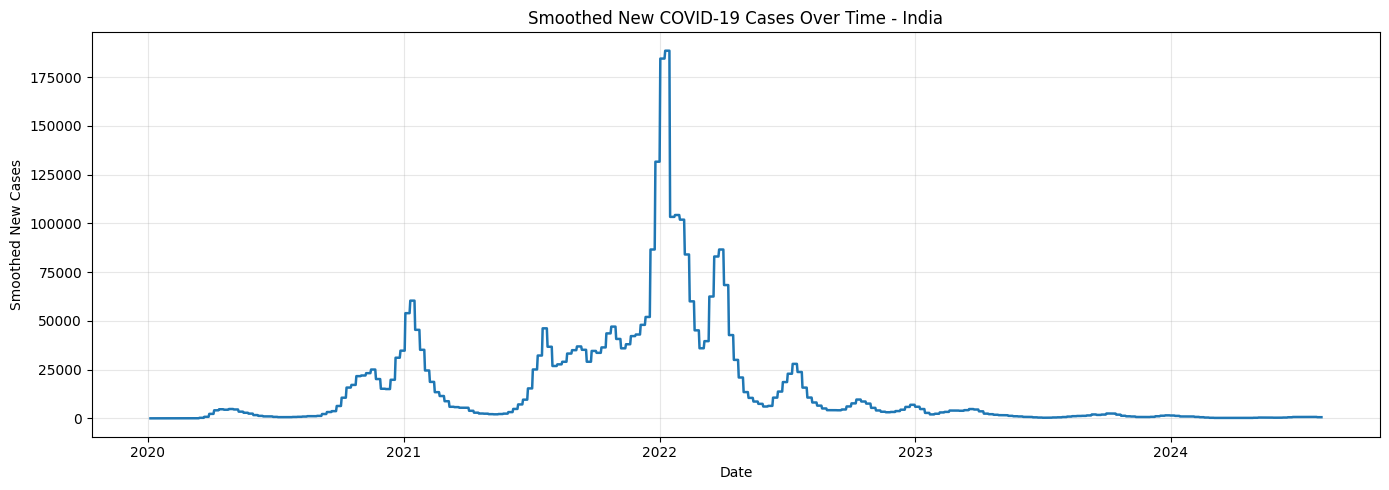

In [25]:
# This plot shows how smoothed new cases changed over time in the selected country.
plt.figure(figsize=(14, 5))
plt.plot(model_df["date"], model_df["new_cases_smoothed"], linewidth=1.8)
plt.title("Smoothed New COVID-19 Cases Over Time - India")
plt.xlabel("Date")
plt.ylabel("Smoothed New Cases")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

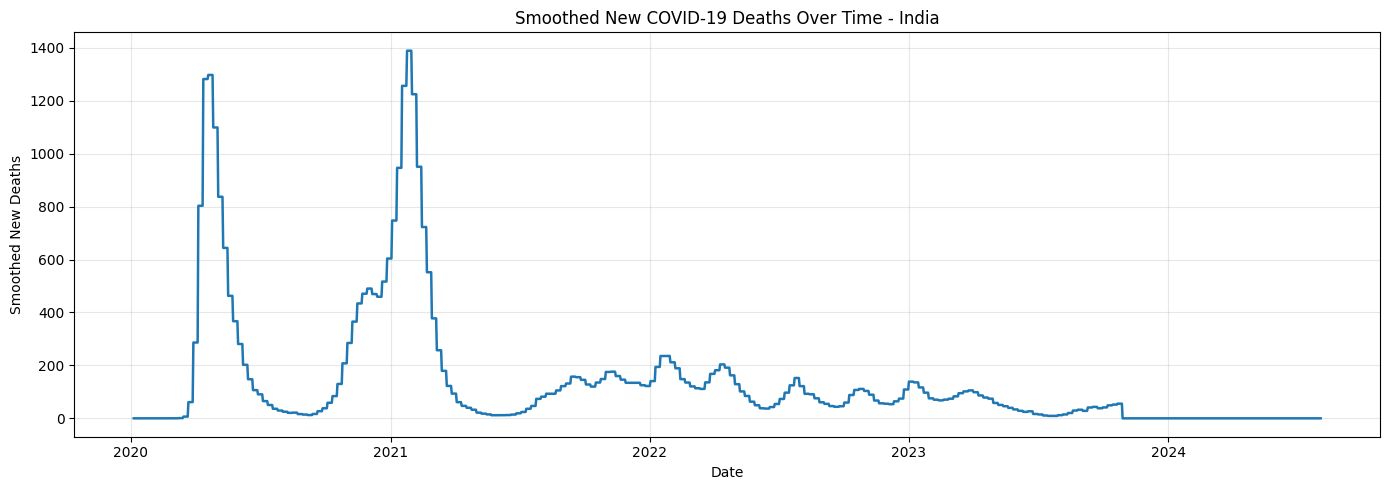

In [26]:
# This plot shows the smoothed death trend
plt.figure(figsize=(14, 5))
plt.plot(model_df["date"], model_df["new_deaths_smoothed"], linewidth=1.8)
plt.title("Smoothed New COVID-19 Deaths Over Time - India")
plt.xlabel("Date")
plt.ylabel("Smoothed New Deaths")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

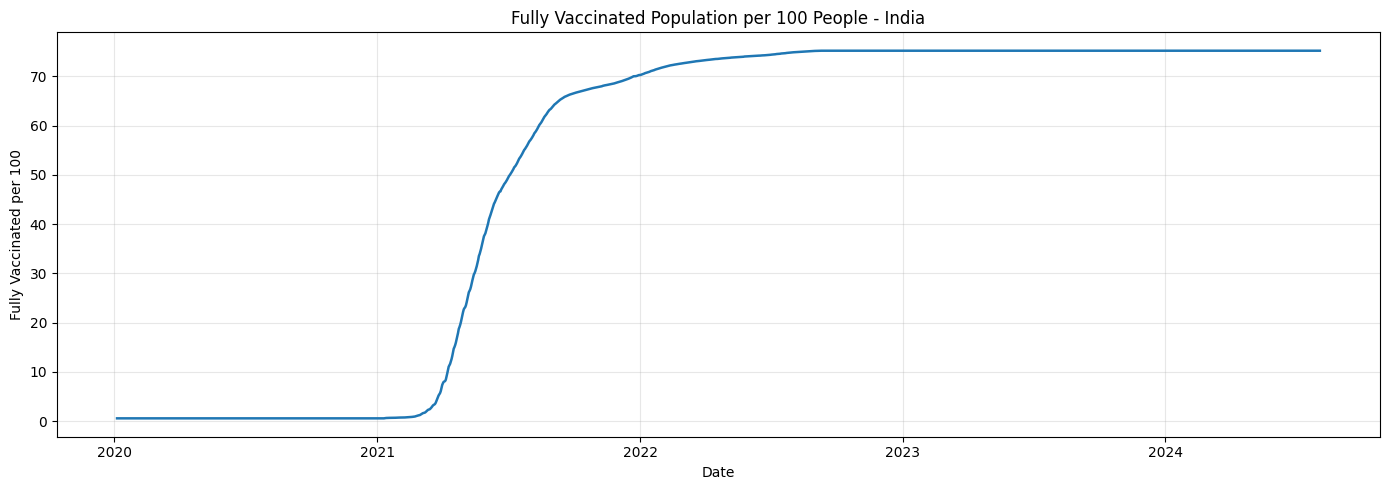

In [27]:
# This plot shows vaccination coverage over time using fully vaccinated population percentage.
plt.figure(figsize=(14, 5))
plt.plot(model_df["date"], model_df["people_fully_vaccinated_per_hundred"], linewidth=1.8)
plt.title("Fully Vaccinated Population per 100 People - India")
plt.xlabel("Date")
plt.ylabel("Fully Vaccinated per 100")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


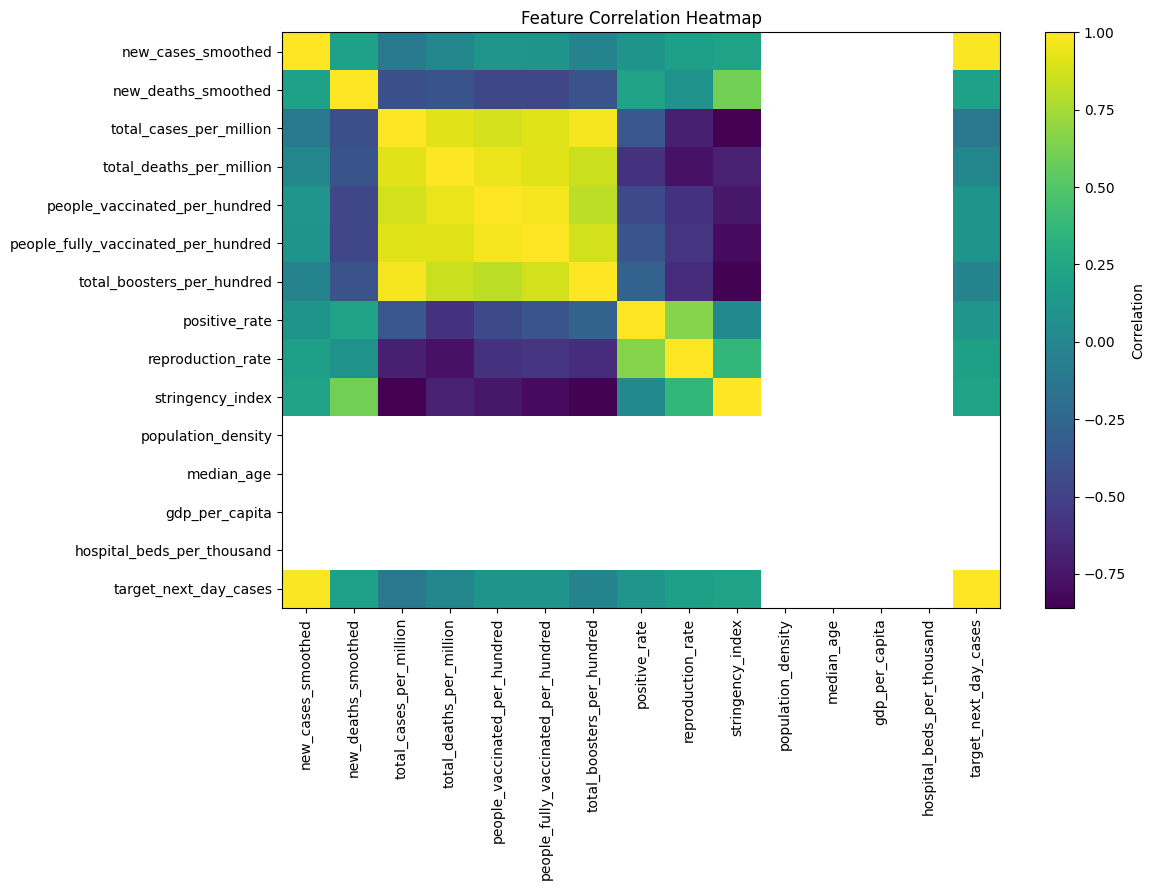

In [28]:
# Correlation analysis
corr_matrix = model_df[feature_columns + ["target_next_day_cases"]].corr(numeric_only=True)
plt.figure(figsize=(12, 9))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(np.arange(corr_matrix.shape[1]), corr_matrix.columns, rotation=90)
plt.yticks(np.arange(corr_matrix.shape[0]), corr_matrix.index)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 4. Data Preparation for Deep Learning

* Chronological train-test split and scaling

In [29]:
# The lookback window defines how many previous days are used as input to the model.
LOOKBACK_DAYS = 14

# The final 20% of the time-series is used as unseen test data.
TEST_SIZE_RATIO = 0.20

# The split index is calculated using chronological order.
split_index = int(len(model_df) * (1 - TEST_SIZE_RATIO))

# Earlier rows are used for training.
train_df = model_df.iloc[:split_index].copy()

# Later rows are used for testing.
test_df = model_df.iloc[split_index:].copy()

# Separate scalers are used for input features and the target variable.
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# The feature scaler is fitted only on training data to avoid test-data leakage.
X_train_scaled = feature_scaler.fit_transform(train_df[feature_columns])

# The fitted feature scaler is then applied to the test data.
X_test_scaled = feature_scaler.transform(test_df[feature_columns])

# The target scaler is fitted only on the training target.
y_train_scaled = target_scaler.fit_transform(train_df[["target_next_day_cases"]])

# The fitted target scaler is applied to the test target.
y_test_scaled = target_scaler.transform(test_df[["target_next_day_cases"]])

In [30]:
# This summary confirms the chronological split sizes.
split_summary = pd.DataFrame({
    "dataset_part": ["Training", "Testing"],
    "rows": [len(train_df), len(test_df)],
    "start_date": [train_df["date"].min(), test_df["date"].min()],
    "end_date": [train_df["date"].max(), test_df["date"].max()]
})

split_summary

,dataset_part,rows,start_date,end_date
0,Training,1338,2020-01-05,2023-09-03
1,Testing,335,2023-09-04,2024-08-03


#### Create time-series sequences

In [31]:
# Sliding windows convert normal tabular rows into 3D sequence tensors for LSTM.
X_train_seq = np.lib.stride_tricks.sliding_window_view(X_train_scaled, window_shape=LOOKBACK_DAYS, axis=0)
X_train_seq = np.swapaxes(X_train_seq, 1, 2)

In [32]:
# Test sequences are created in the same way using later unseen records.
X_test_seq = np.lib.stride_tricks.sliding_window_view(X_test_scaled, window_shape=LOOKBACK_DAYS, axis=0)
X_test_seq = np.swapaxes(X_test_seq, 1, 2)

In [33]:
# The target value is aligned with the final day of each input sequence.
y_train_seq = y_train_scaled[LOOKBACK_DAYS - 1:]
y_test_seq = y_test_scaled[LOOKBACK_DAYS - 1:]

In [34]:
# ANN baseline uses the same sequence information but in flattened 2D format.
X_train_ann = X_train_seq.reshape(X_train_seq.shape[0], LOOKBACK_DAYS * len(feature_columns))
X_test_ann = X_test_seq.reshape(X_test_seq.shape[0], LOOKBACK_DAYS * len(feature_columns))

In [35]:
# This summary verifies that both ANN and LSTM input shapes are ready.
sequence_summary = pd.DataFrame({
    "item": ["X_train_seq", "X_test_seq", "y_train_seq", "y_test_seq", "X_train_ann", "X_test_ann"],
    "shape": [str(X_train_seq.shape), str(X_test_seq.shape), str(y_train_seq.shape), str(y_test_seq.shape), str(X_train_ann.shape), str(X_test_ann.shape)]
})

sequence_summary

,item,shape
0,X_train_seq,"(1325, 14, 14)"
1,X_test_seq,"(322, 14, 14)"
2,y_train_seq,"(1325, 1)"
3,y_test_seq,"(322, 1)"
4,X_train_ann,"(1325, 196)"
5,X_test_ann,"(322, 196)"


## Build Model 1: ANN baseline

In [36]:
ann_model = Sequential(name="ANN_Baseline_COVID_Cases")
ann_model.add(Input(shape=(X_train_ann.shape[1],)))
ann_model.add(Dense(128, activation="relu"))
ann_model.add(Dropout(0.20))
ann_model.add(Dense(64, activation="relu"))
ann_model.add(Dropout(0.20))
ann_model.add(Dense(32, activation="relu"))
ann_model.add(Dense(1, activation="linear"))
ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

In [37]:
# The architecture summary
ann_model.summary()

Model: "ANN_Baseline_COVID_Cases"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        25,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,585 (139.00 KB)

 Trainable params: 35,585 (139.00 KB)

 Non-trainable params: 0 (0.00 B)

### Train Model 1: ANN baseline

In [38]:
# Early stopping
ann_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [39]:
# Learning-rate reduction
ann_lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=0.00001
)

In [40]:
# The model is trained with chronological validation because shuffle is disabled.
ann_history = ann_model.fit(
    X_train_ann,
    y_train_seq,
    validation_split=0.20,
    epochs=60,
    batch_size=32,
    shuffle=False,
    callbacks=[ann_early_stop, ann_lr_reduce],
    verbose=1
)

Epoch 1/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0598 - mae: 0.1851 - val_loss: 0.0139 - val_mae: 0.1176 - learning_rate: 0.0010
Epoch 2/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0459 - mae: 0.1557 - val_loss: 0.0012 - val_mae: 0.0338 - learning_rate: 0.0010
Epoch 3/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0342 - mae: 0.1284 - val_loss: 6.2303e-05 - val_mae: 0.0071 - learning_rate: 0.0010
Epoch 4/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0358 - mae: 0.1229 - val_loss: 0.0080 - val_mae: 0.0890 - learning_rate: 0.0010
Epoch 5/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0235 - mae: 0.1014 - val_loss: 1.6782e-04 - val_mae: 0.0108 - learning_rate: 0.0010
Epoch 6/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0137 - mae: 0.0745 - val_loss: 2.1442e-04 - val_mae: 0.0139 - learning_rate: 0.0010
Epoch 7/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0127 - mae: 0.0757 - val_loss: 1.0745e-04 - val_mae: 0.0091 - learning_rate: 0.0010
Epo

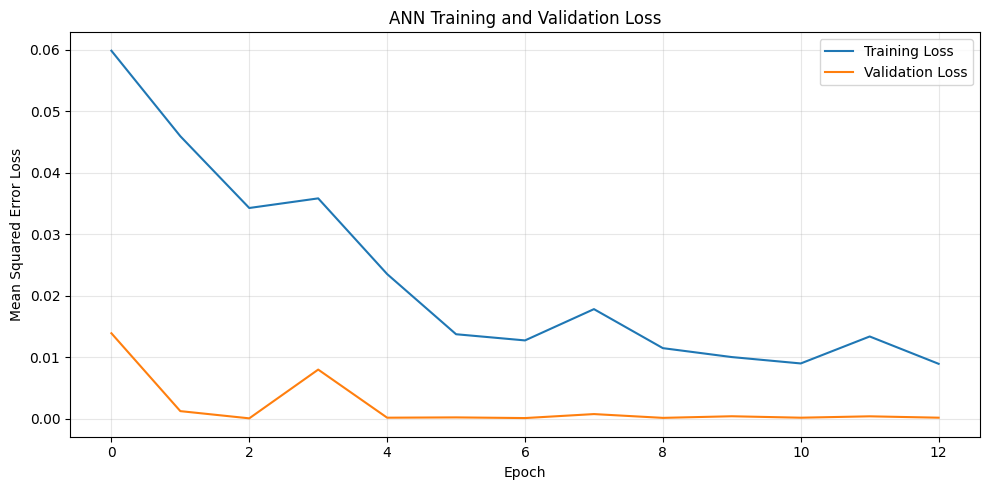

In [41]:
# The loss curve
plt.figure(figsize=(10, 5))
plt.plot(ann_history.history["loss"], label="Training Loss")
plt.plot(ann_history.history["val_loss"], label="Validation Loss")
plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* Test Model 1 on unseen data

In [42]:
# The trained ANN predicts target values for the unseen test period.
ann_pred_scaled = ann_model.predict(X_test_ann)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [43]:
# Predictions are converted back to the original case-count scale.
ann_predictions = target_scaler.inverse_transform(ann_pred_scaled)

# Actual test target values are also converted back to the original scale.
ann_actual = target_scaler.inverse_transform(y_test_seq)

In [44]:
# Regression metrics evaluate the ANN model performance.
ann_mae = mean_absolute_error(ann_actual, ann_predictions)
ann_rmse = np.sqrt(mean_squared_error(ann_actual, ann_predictions))
ann_r2 = r2_score(ann_actual, ann_predictions)
ann_mape = np.mean(np.abs((ann_actual.flatten() - ann_predictions.flatten()) / np.maximum(ann_actual.flatten(), 1))) * 100

In [45]:
# metrics table
ann_metrics = pd.DataFrame({
    "Model": ["Baseline ANN"],
    "MAE": [ann_mae],
    "RMSE": [ann_rmse],
    "R2_Score": [ann_r2],
    "MAPE_Percentage": [ann_mape]
})

ann_metrics

,Model,MAE,RMSE,R2_Score,MAPE_Percentage
0,Baseline ANN,1386.65156,1455.314377,-5.311484,329.04359


* Visualise Model 1 actual vs predicted values

In [46]:
# Prediction dates are aligned with the available test sequences.
ann_results = pd.DataFrame({
    "date": test_df["date"].iloc[LOOKBACK_DAYS - 1:].reset_index(drop=True),
    "actual_next_day_cases": ann_actual.flatten(),
    "ann_predicted_next_day_cases": ann_predictions.flatten()
})

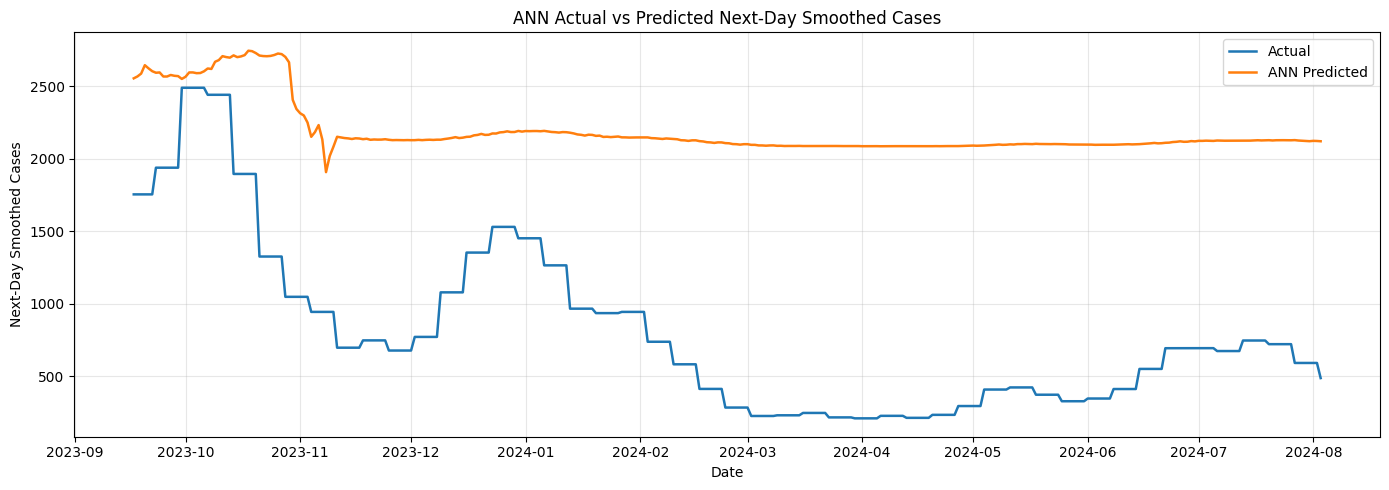

In [47]:
# The line chart compares actual and predicted values over the unseen test period.
plt.figure(figsize=(14, 5))
plt.plot(ann_results["date"], ann_results["actual_next_day_cases"], label="Actual", linewidth=1.8)
plt.plot(ann_results["date"], ann_results["ann_predicted_next_day_cases"], label="ANN Predicted", linewidth=1.8)
plt.title("ANN Actual vs Predicted Next-Day Smoothed Cases")
plt.xlabel("Date")
plt.ylabel("Next-Day Smoothed Cases")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# Display the first few ANN predictions
ann_results.head()

,date,actual_next_day_cases,ann_predicted_next_day_cases
0,2023-09-17,1753.29,2553.919922
1,2023-09-18,1753.29,2566.946777
2,2023-09-19,1753.29,2586.551758
3,2023-09-20,1753.29,2644.623535
4,2023-09-21,1753.29,2622.750977


#### Build Model 2: LSTM network


In [49]:
lstm_model = Sequential(name="LSTM_COVID_Cases")
lstm_model.add(Input(shape=(LOOKBACK_DAYS, len(feature_columns))))
lstm_model.add(LSTM(64, activation="tanh", return_sequences=True))
lstm_model.add(Dropout(0.20))
lstm_model.add(LSTM(32, activation="tanh", return_sequences=False))
lstm_model.add(Dropout(0.20))
lstm_model.add(Dense(32, activation="relu"))
lstm_model.add(Dense(16, activation="relu"))
lstm_model.add(Dense(1, activation="linear"))

In [50]:
# Compile Model
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

In [51]:
# The model summary
lstm_model.summary()

Model: "LSTM_COVID_Cases"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,241 (133.75 KB)

 Trainable params: 34,241 (133.75 KB)

 Non-trainable params: 0 (0.00 B)

* Train Model 2: LSTM network

In [52]:
# Early stopping is applied again to reduce overfitting risk.
lstm_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [53]:
# Learning-rate reduction supports fine-tuning during LSTM training.
lstm_lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=0.00001
)

In [54]:
# The LSTM is trained on 3D sequence data with shuffle disabled for time-series order.
lstm_history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.20,
    epochs=60,
    batch_size=32,
    shuffle=False,
    callbacks=[lstm_early_stop, lstm_lr_reduce],
    verbose=1
)

Epoch 1/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0348 - mae: 0.1348 - val_loss: 9.0506e-04 - val_mae: 0.0289 - learning_rate: 0.0010
Epoch 2/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0392 - mae: 0.1433 - val_loss: 0.0036 - val_mae: 0.0591 - learning_rate: 0.0010
Epoch 3/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0334 - mae: 0.1380 - val_loss: 0.0065 - val_mae: 0.0807 - learning_rate: 0.0010
Epoch 4/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0378 - mae: 0.1334 - val_loss: 0.0047 - val_mae: 0.0684 - learning_rate: 0.0010
Epoch 5/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0226 - mae: 0.0986 - val_loss: 0.0011 - val_mae: 0.0329 - learning_rate: 0.0010
Epoch 6/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0232 - mae: 0.1043 - val_loss: 0.0014 - val_mae: 0.0366 - learning_rate: 0.0010
Epoch 7/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0121 - mae: 0.0719 - val_loss: 6.6866e-04 - val_mae: 0.0251 - learning_rate: 5.0000e-04
E

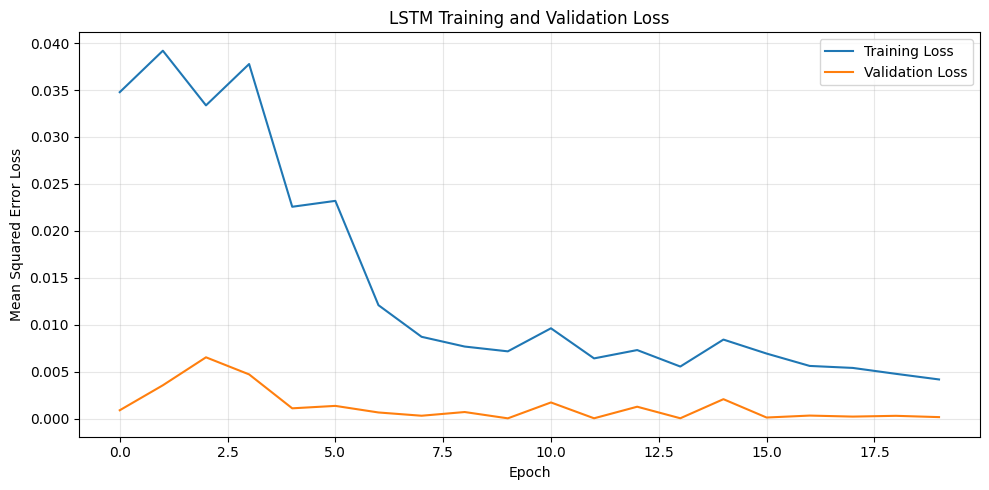

In [55]:
# The LSTM loss curve
plt.figure(figsize=(10, 5))
plt.plot(lstm_history.history["loss"], label="Training Loss")
plt.plot(lstm_history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* Test Model 2 on unseen data

In [56]:
# The trained LSTM predicts values for the unseen test sequences.
lstm_pred_scaled = lstm_model.predict(X_test_seq)

# Predictions are inverse transformed back to original case-count scale.
lstm_predictions = target_scaler.inverse_transform(lstm_pred_scaled)

# Actual test targets are inverse transformed for metric calculation.
lstm_actual = target_scaler.inverse_transform(y_test_seq)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


In [57]:
# Regression metrics evaluate the LSTM model performance.
lstm_mae = mean_absolute_error(lstm_actual, lstm_predictions)
lstm_rmse = np.sqrt(mean_squared_error(lstm_actual, lstm_predictions))
lstm_r2 = r2_score(lstm_actual, lstm_predictions)
lstm_mape = np.mean(np.abs((lstm_actual.flatten() - lstm_predictions.flatten()) / np.maximum(lstm_actual.flatten(), 1))) * 100

In [58]:
# A clean LSTM metrics table
lstm_metrics = pd.DataFrame({
    "Model": ["LSTM"],
    "MAE": [lstm_mae],
    "RMSE": [lstm_rmse],
    "R2_Score": [lstm_r2],
    "MAPE_Percentage": [lstm_mape]
})

lstm_metrics

,Model,MAE,RMSE,R2_Score,MAPE_Percentage
0,LSTM,533.094611,590.827078,-0.040252,136.427017


In [59]:
# LSTM prediction results are stored separately for clean reporting.
lstm_results = pd.DataFrame({
    "date": test_df["date"].iloc[LOOKBACK_DAYS - 1:].reset_index(drop=True),
    "actual_next_day_cases": lstm_actual.flatten(),
    "lstm_predicted_next_day_cases": lstm_predictions.flatten()
})

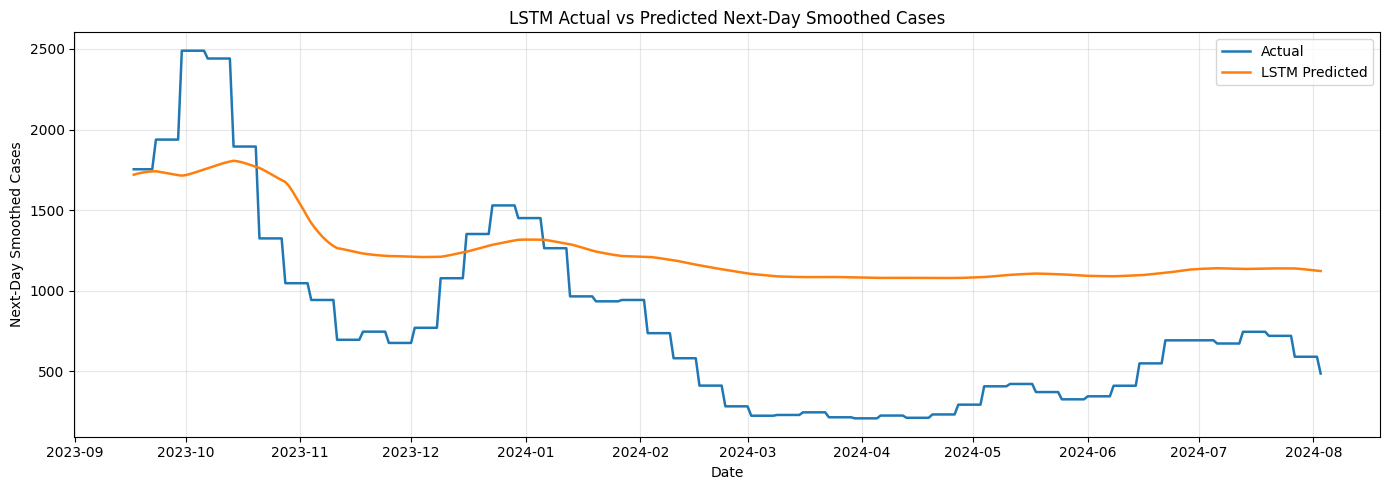

In [60]:
# The line chart compares LSTM predictions with actual unseen values.
plt.figure(figsize=(14, 5))
plt.plot(lstm_results["date"], lstm_results["actual_next_day_cases"], label="Actual", linewidth=1.8)
plt.plot(lstm_results["date"], lstm_results["lstm_predicted_next_day_cases"], label="LSTM Predicted", linewidth=1.8)
plt.title("LSTM Actual vs Predicted Next-Day Smoothed Cases")
plt.xlabel("Date")
plt.ylabel("Next-Day Smoothed Cases")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
# Display the first few LSTM predictions
lstm_results.head()

,date,actual_next_day_cases,lstm_predicted_next_day_cases
0,2023-09-17,1753.29,1719.508789
1,2023-09-18,1753.29,1726.108765
2,2023-09-19,1753.29,1731.207764
3,2023-09-20,1753.29,1735.086792
4,2023-09-21,1753.29,1737.944824


## 5. Model Comparison and Results Analysis

In [62]:
# Both metric tables are combined for final model comparison.
model_comparison = pd.concat([ann_metrics, lstm_metrics], ignore_index=True)

In [63]:
model_comparison = model_comparison.sort_values("RMSE", ascending=True).reset_index(drop=True)

In [64]:
# Display the final comparison table.
model_comparison

,Model,MAE,RMSE,R2_Score,MAPE_Percentage
0,LSTM,533.094611,590.827078,-0.040252,136.427017
1,Baseline ANN,1386.651560,1455.314377,-5.311484,329.043590


* Combined prediction comparison chart

In [65]:
# A combined table is created to compare both model predictions against the same actual values.
combined_results = pd.DataFrame({
    "date": test_df["date"].iloc[LOOKBACK_DAYS - 1:].reset_index(drop=True),
    "actual_next_day_cases": lstm_actual.flatten(),
    "ann_predicted_next_day_cases": ann_predictions.flatten(),
    "lstm_predicted_next_day_cases": lstm_predictions.flatten()
})

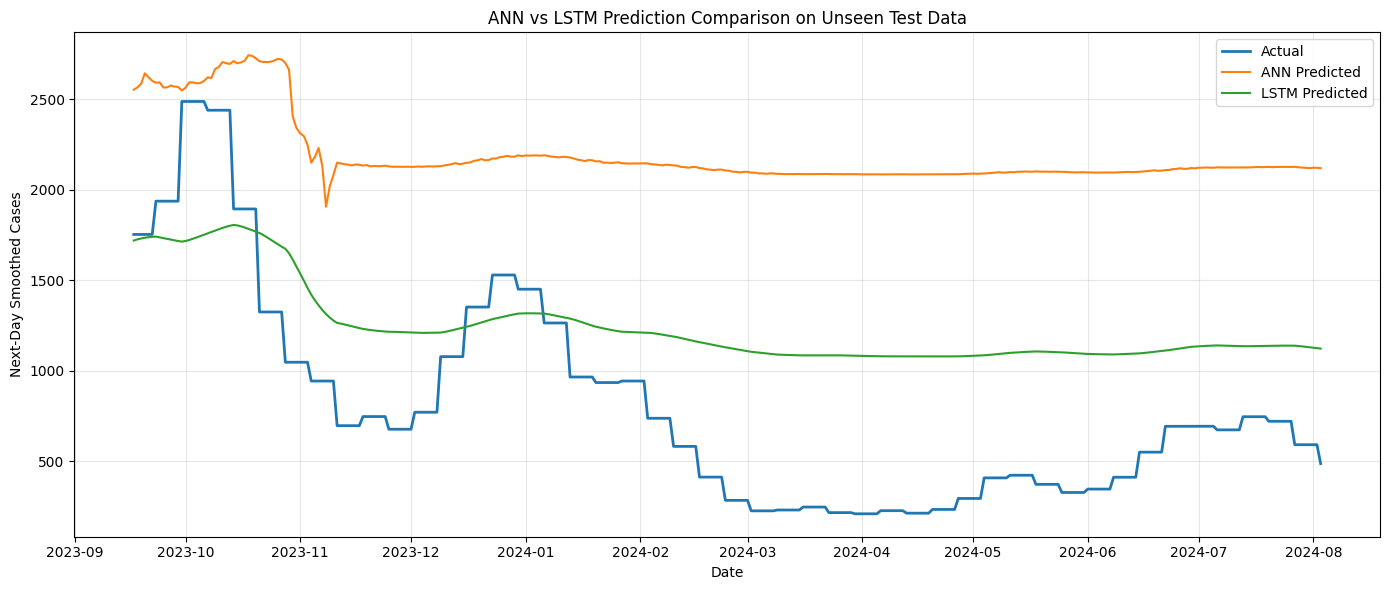

In [66]:
# This chart visually compares ANN, LSTM, and actual next-day smoothed cases.
plt.figure(figsize=(14, 6))
plt.plot(combined_results["date"], combined_results["actual_next_day_cases"], label="Actual", linewidth=2.0)
plt.plot(combined_results["date"], combined_results["ann_predicted_next_day_cases"], label="ANN Predicted", linewidth=1.5)
plt.plot(combined_results["date"], combined_results["lstm_predicted_next_day_cases"], label="LSTM Predicted", linewidth=1.5)
plt.title("ANN vs LSTM Prediction Comparison on Unseen Test Data")
plt.xlabel("Date")
plt.ylabel("Next-Day Smoothed Cases")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
# Display combined prediction values.
combined_results.head()

,date,actual_next_day_cases,ann_predicted_next_day_cases,lstm_predicted_next_day_cases
0,2023-09-17,1753.29,2553.919922,1719.508789
1,2023-09-18,1753.29,2566.946777,1726.108765
2,2023-09-19,1753.29,2586.551758,1731.207764
3,2023-09-20,1753.29,2644.623535,1735.086792
4,2023-09-21,1753.29,2622.750977,1737.944824


* Error analysis for the best model

In [68]:
# The best model is identified from the sorted comparison table.
best_model_name = model_comparison.loc[0, "Model"]

In [69]:
# The best prediction column is selected using a simple condition.
best_predictions = np.where(best_model_name == "LSTM", lstm_predictions.flatten(), ann_predictions.flatten())

In [70]:
# The actual values are taken from the same test period.
best_actual = lstm_actual.flatten()

In [71]:
# Residuals show where the model over-predicts or under-predicts.
residuals = best_actual - best_predictions

In [72]:
# A residual table is created for additional report analysis.
residual_analysis = pd.DataFrame({
    "date": combined_results["date"],
    "actual_next_day_cases": best_actual,
    "best_model_prediction": best_predictions,
    "residual_error": residuals
})

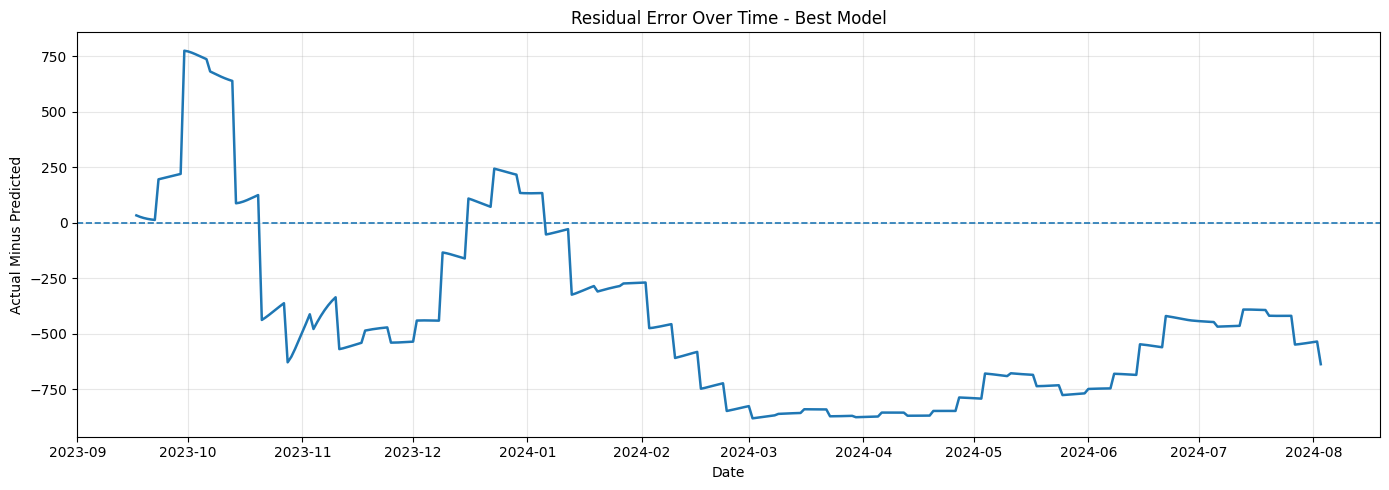

In [73]:
# The residual plot shows the error pattern over time.
plt.figure(figsize=(14, 5))
plt.plot(residual_analysis["date"], residual_analysis["residual_error"], linewidth=1.8)
plt.axhline(0, linestyle="--", linewidth=1.2)
plt.title("Residual Error Over Time - Best Model")
plt.xlabel("Date")
plt.ylabel("Actual Minus Predicted")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [74]:
# Display the best model name and residual sample.
print("Best model based on RMSE:", best_model_name)
residual_analysis.head()

Best model based on RMSE: LSTM


,date,actual_next_day_cases,best_model_prediction,residual_error
0,2023-09-17,1753.29,1719.508789,33.781211
1,2023-09-18,1753.29,1726.108765,27.181235
2,2023-09-19,1753.29,1731.207764,22.082236
3,2023-09-20,1753.29,1735.086792,18.203208
4,2023-09-21,1753.29,1737.944824,15.345176


## 6. Testing with New Data

In [75]:
# The latest available 14 days are selected as the new input window.
latest_feature_block = model_df[feature_columns].tail(LOOKBACK_DAYS).copy()

# The latest block is scaled with the already fitted training scaler.
latest_feature_scaled = feature_scaler.transform(latest_feature_block)

In [76]:
# ANN requires the new input in flattened 2D format.
latest_ann_input = latest_feature_scaled.reshape(1, LOOKBACK_DAYS * len(feature_columns))

# LSTM requires the new input in 3D sequence format.
latest_lstm_input = latest_feature_scaled.reshape(1, LOOKBACK_DAYS, len(feature_columns))

In [77]:
# Both trained models produce one next-day prediction.
latest_ann_pred_scaled = ann_model.predict(latest_ann_input)
latest_lstm_pred_scaled = lstm_model.predict(latest_lstm_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [78]:
# Predictions are converted back to original case-count scale.
latest_ann_prediction = target_scaler.inverse_transform(latest_ann_pred_scaled)[0, 0]
latest_lstm_prediction = target_scaler.inverse_transform(latest_lstm_pred_scaled)[0, 0]

In [79]:
# The prediction date is one day after the latest available dataset date.
next_prediction_date = model_df["date"].max() + pd.Timedelta(days=1)

In [80]:
# A compact prediction table is created for demo and report use.
new_data_prediction = pd.DataFrame({
    "country": [SELECTED_COUNTRY],
    "latest_data_date": [model_df["date"].max()],
    "prediction_date": [next_prediction_date],
    "ann_predicted_next_day_cases": [latest_ann_prediction],
    "lstm_predicted_next_day_cases": [latest_lstm_prediction],
    "best_model_based_on_rmse": [best_model_name]
})

new_data_prediction

,country,latest_data_date,prediction_date,ann_predicted_next_day_cases,lstm_predicted_next_day_cases,best_model_based_on_rmse
0,United Kingdom,2024-08-03,2024-08-04,2119.777832,1121.887329,LSTM


## Save Models, Results, and Deployment Assets

In [81]:
# The output folder stores all practical artefacts in one place.
OUTPUT_DIR = "covid_deep_learning_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [82]:
# Trained Keras models are saved in the modern .keras format.
ann_model.save(os.path.join(OUTPUT_DIR, "ann_baseline_covid_cases.keras"))
lstm_model.save(os.path.join(OUTPUT_DIR, "lstm_covid_cases.keras"))

In [83]:
# Fitted scalers are saved so future data can be transformed in the same way.
joblib.dump(feature_scaler, os.path.join(OUTPUT_DIR, "feature_scaler.pkl"))
joblib.dump(target_scaler, os.path.join(OUTPUT_DIR, "target_scaler.pkl"))

['covid_deep_learning_outputs/target_scaler.pkl']

In [84]:
# Clean data, metrics, predictions, and residuals are saved as CSV files.
model_df.to_csv(os.path.join(OUTPUT_DIR, "clean_india_covid_model_data.csv"), index=False)
ann_metrics.to_csv(os.path.join(OUTPUT_DIR, "ann_evaluation_metrics.csv"), index=False)
lstm_metrics.to_csv(os.path.join(OUTPUT_DIR, "lstm_evaluation_metrics.csv"), index=False)
model_comparison.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_metrics.csv"), index=False)
combined_results.to_csv(os.path.join(OUTPUT_DIR, "combined_predictions.csv"), index=False)
residual_analysis.to_csv(os.path.join(OUTPUT_DIR, "best_model_residual_analysis.csv"), index=False)
new_data_prediction.to_csv(os.path.join(OUTPUT_DIR, "latest_next_day_prediction.csv"), index=False)

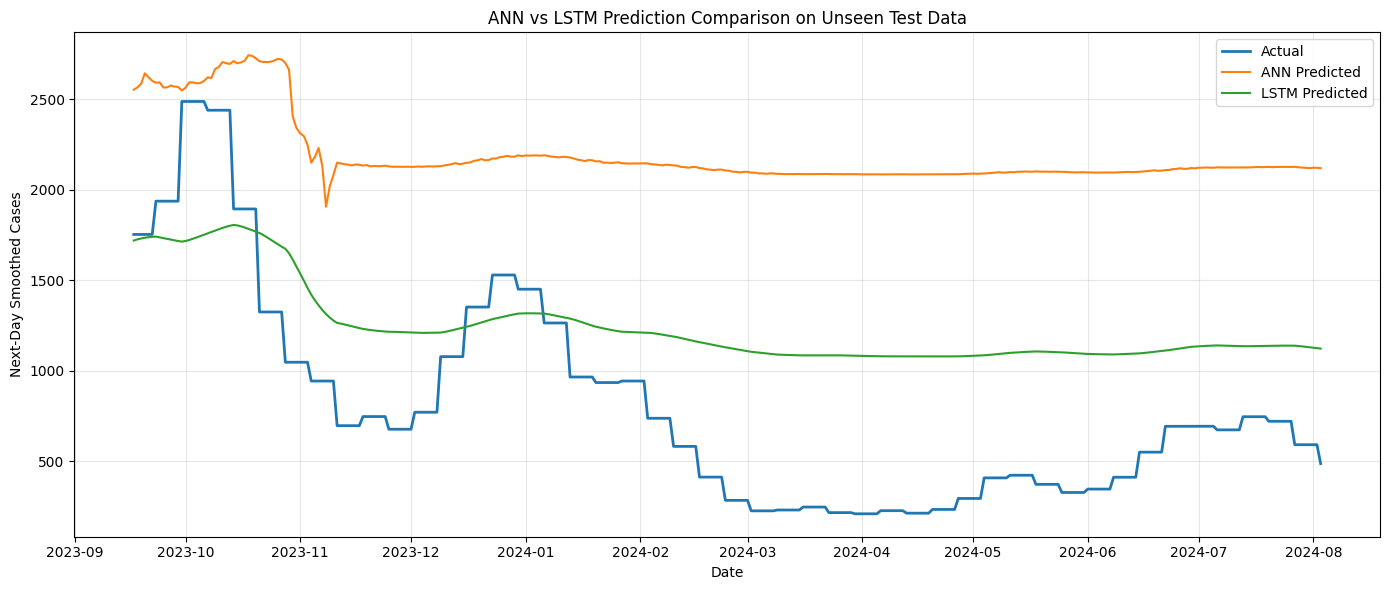

In [85]:
# combined prediction figure
plt.figure(figsize=(14, 6))
plt.plot(combined_results["date"], combined_results["actual_next_day_cases"], label="Actual", linewidth=2.0)
plt.plot(combined_results["date"], combined_results["ann_predicted_next_day_cases"], label="ANN Predicted", linewidth=1.5)
plt.plot(combined_results["date"], combined_results["lstm_predicted_next_day_cases"], label="LSTM Predicted", linewidth=1.5)
plt.title("ANN vs LSTM Prediction Comparison on Unseen Test Data")
plt.xlabel("Date")
plt.ylabel("Next-Day Smoothed Cases")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ann_lstm_prediction_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

## Model Deployment Using Streamlit and Ngrok

This section is added at the end of the notebook for deployment only. The previous training, evaluation, visualisation, testing, and saving code is not changed. The cells below save the final best-model deployment artefact, write a Streamlit application, and run it through an ngrok public URL.


In [86]:
# Deployment artifact preparation
# This cell uses the models, scalers, results, and settings that were already created in the notebook.
# No previous training, evaluation, or visualisation code is changed.

import json
import os

# The original notebook already created this output folder.
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Select the best trained model according to the existing RMSE-based comparison table.
best_model_name = model_comparison.loc[0, "Model"]
print("Best model selected for deployment:", best_model_name)

# Match the correct trained model object with the best model name.
deployment_model = lstm_model if best_model_name == "LSTM" else ann_model

# Save the selected best model separately for a simple deployment workflow.
deployment_model.save(os.path.join(OUTPUT_DIR, "best_covid_cases_model.keras"))

# Save deployment configuration required by the Streamlit application.
deployment_config = {
    "selected_country": str(SELECTED_COUNTRY),
    "best_model_name": str(best_model_name),
    "lookback_days": int(LOOKBACK_DAYS),
    "feature_columns": list(feature_columns),
    "target_column": "target_next_day_cases",
    "ann_model_file": "ann_baseline_covid_cases.keras",
    "lstm_model_file": "lstm_covid_cases.keras",
    "best_model_file": "best_covid_cases_model.keras",
    "feature_scaler_file": "feature_scaler.pkl",
    "target_scaler_file": "target_scaler.pkl",
    "clean_data_file": "clean_india_covid_model_data.csv",
    "comparison_file": "model_comparison_metrics.csv",
    "combined_predictions_file": "combined_predictions.csv",
    "latest_prediction_file": "latest_next_day_prediction.csv"
}

with open(os.path.join(OUTPUT_DIR, "deployment_config.json"), "w") as file:
    json.dump(deployment_config, file, indent=4)

# Check that the required deployment files are available.
deployment_status = pd.DataFrame({
    "artifact": [
        "best_covid_cases_model.keras",
        "deployment_config.json",
        "feature_scaler.pkl",
        "target_scaler.pkl",
        "clean_india_covid_model_data.csv",
        "model_comparison_metrics.csv",
        "combined_predictions.csv",
        "latest_next_day_prediction.csv"
    ],
    "available": [
        os.path.exists(os.path.join(OUTPUT_DIR, "best_covid_cases_model.keras")),
        os.path.exists(os.path.join(OUTPUT_DIR, "deployment_config.json")),
        os.path.exists(os.path.join(OUTPUT_DIR, "feature_scaler.pkl")),
        os.path.exists(os.path.join(OUTPUT_DIR, "target_scaler.pkl")),
        os.path.exists(os.path.join(OUTPUT_DIR, "clean_india_covid_model_data.csv")),
        os.path.exists(os.path.join(OUTPUT_DIR, "model_comparison_metrics.csv")),
        os.path.exists(os.path.join(OUTPUT_DIR, "combined_predictions.csv")),
        os.path.exists(os.path.join(OUTPUT_DIR, "latest_next_day_prediction.csv"))
    ]
})

print(deployment_status.to_string(index=False))

if deployment_status["available"].all():
    print("All required deployment artefacts are available.")
else:
    print("Run the previous model-saving cells before starting deployment.")


Best model selected for deployment: LSTM
                        artifact  available
    best_covid_cases_model.keras       True
          deployment_config.json       True
              feature_scaler.pkl       True
               target_scaler.pkl       True
clean_india_covid_model_data.csv       True
    model_comparison_metrics.csv       True
        combined_predictions.csv       True
  latest_next_day_prediction.csv       True
All required deployment artefacts are available.


### Streamlit App Code


In [87]:
%%writefile covid_streamlit_app.py
import os
import json
import numpy as np
import pandas as pd
import streamlit as st
import tensorflow as tf
import joblib

st.set_page_config(
    page_title="COVID-19 Deep Learning Deployment",
    page_icon="🦠",
    layout="wide"
)

st.title("COVID-19 New Cases Prediction Deployment App")
st.write(
    "This Streamlit app loads the saved deep learning model, fitted scalers, "
    "clean modelling dataset, and evaluation outputs from the notebook. It predicts "
    "the next-day smoothed COVID-19 cases using the latest 14-day feature window."
)

ARTIFACT_DIR = "covid_deep_learning_outputs"
CONFIG_PATH = os.path.join(ARTIFACT_DIR, "deployment_config.json")
FEATURE_SCALER_PATH = os.path.join(ARTIFACT_DIR, "feature_scaler.pkl")
TARGET_SCALER_PATH = os.path.join(ARTIFACT_DIR, "target_scaler.pkl")
MODEL_DATA_PATH = os.path.join(ARTIFACT_DIR, "clean_india_covid_model_data.csv")
COMPARISON_PATH = os.path.join(ARTIFACT_DIR, "model_comparison_metrics.csv")
COMBINED_PREDICTIONS_PATH = os.path.join(ARTIFACT_DIR, "combined_predictions.csv")
LATEST_PREDICTION_PATH = os.path.join(ARTIFACT_DIR, "latest_next_day_prediction.csv")
PLOT_PATH = os.path.join(ARTIFACT_DIR, "ann_lstm_prediction_comparison.png")

required_files = [
    CONFIG_PATH,
    FEATURE_SCALER_PATH,
    TARGET_SCALER_PATH,
    MODEL_DATA_PATH
]

missing_files = [path for path in required_files if not os.path.exists(path)]

if len(missing_files) > 0:
    st.error("Some required deployment files are missing. Please run the notebook training and deployment artifact cells first.")
    st.write("Missing files:")
    st.write(missing_files)
    st.stop()

with open(CONFIG_PATH, "r") as file:
    config = json.load(file)

best_model_name = config["best_model_name"]
lookback_days = int(config["lookback_days"])
feature_columns = config["feature_columns"]
selected_country = config["selected_country"]
model_file = config["best_model_file"]
model_path = os.path.join(ARTIFACT_DIR, model_file)

if not os.path.exists(model_path):
    st.error("Saved best model file was not found. Please run the deployment artifact-saving cell again.")
    st.write("Expected model path:", model_path)
    st.stop()

@st.cache_resource
def load_model_and_scalers():
    loaded_model = tf.keras.models.load_model(model_path, compile=False)
    loaded_feature_scaler = joblib.load(FEATURE_SCALER_PATH)
    loaded_target_scaler = joblib.load(TARGET_SCALER_PATH)
    return loaded_model, loaded_feature_scaler, loaded_target_scaler

model, feature_scaler, target_scaler = load_model_and_scalers()
model_df = pd.read_csv(MODEL_DATA_PATH)
model_df["date"] = pd.to_datetime(model_df["date"], errors="coerce")

st.sidebar.header("Deployment Information")
st.sidebar.write("Selected country:", selected_country)
st.sidebar.write("Best deployed model:", best_model_name)
st.sidebar.write("Lookback window:", str(lookback_days) + " days")
st.sidebar.write("Input features:", len(feature_columns))

st.subheader("Saved Model Performance")
if os.path.exists(COMPARISON_PATH):
    comparison_df = pd.read_csv(COMPARISON_PATH)
    st.dataframe(comparison_df, use_container_width=True)
else:
    st.info("Model comparison CSV is not available.")

st.subheader("Latest Next-Day Prediction from Saved Dataset")
latest_block = model_df[feature_columns].tail(lookback_days).copy()
latest_scaled = feature_scaler.transform(latest_block)

if best_model_name == "LSTM":
    model_input = latest_scaled.reshape(1, lookback_days, len(feature_columns))
else:
    model_input = latest_scaled.reshape(1, lookback_days * len(feature_columns))

pred_scaled = model.predict(model_input, verbose=0)
pred_value = target_scaler.inverse_transform(pred_scaled)[0, 0]
pred_value = max(float(pred_value), 0.0)
latest_data_date = model_df["date"].max()
prediction_date = latest_data_date + pd.Timedelta(days=1)

metric_col1, metric_col2, metric_col3 = st.columns(3)
metric_col1.metric("Latest data date", latest_data_date.strftime("%Y-%m-%d"))
metric_col2.metric("Prediction date", prediction_date.strftime("%Y-%m-%d"))
metric_col3.metric("Predicted next-day smoothed cases", f"{pred_value:,.0f}")

if os.path.exists(LATEST_PREDICTION_PATH):
    with st.expander("Notebook saved latest-prediction table"):
        st.dataframe(pd.read_csv(LATEST_PREDICTION_PATH), use_container_width=True)

st.subheader("Prediction Trend on Unseen Test Data")
if os.path.exists(COMBINED_PREDICTIONS_PATH):
    combined_df = pd.read_csv(COMBINED_PREDICTIONS_PATH)
    combined_df["date"] = pd.to_datetime(combined_df["date"], errors="coerce")
    chart_df = combined_df.set_index("date")[[
        "actual_next_day_cases",
        "ann_predicted_next_day_cases",
        "lstm_predicted_next_day_cases"
    ]]
    st.line_chart(chart_df)
else:
    st.info("Combined prediction CSV is not available.")

if os.path.exists(PLOT_PATH):
    with st.expander("Saved comparison plot from notebook"):
        st.image(PLOT_PATH, use_container_width=True)

st.subheader("Upload New 14-Day Feature Data for Prediction")
st.write(
    "Upload a CSV containing the same feature columns used in training. The app will use "
    "the most recent 14 rows for one next-day prediction."
)

uploaded_file = st.file_uploader("Upload feature CSV", type=["csv"])

if uploaded_file is not None:
    upload_df = pd.read_csv(uploaded_file)
    missing_columns = [col for col in feature_columns if col not in upload_df.columns]

    if len(missing_columns) > 0:
        st.error("The uploaded CSV is missing required columns.")
        st.write(missing_columns)
    elif upload_df.shape[0] < lookback_days:
        st.error("The uploaded CSV must contain at least " + str(lookback_days) + " rows.")
    else:
        new_block = upload_df[feature_columns].tail(lookback_days).copy()
        new_block = new_block.apply(pd.to_numeric, errors="coerce")
        new_block = new_block.interpolate(method="linear", limit_direction="both")
        new_block = new_block.ffill().bfill().fillna(0).clip(lower=0)

        new_scaled = feature_scaler.transform(new_block)

        if best_model_name == "LSTM":
            new_input = new_scaled.reshape(1, lookback_days, len(feature_columns))
        else:
            new_input = new_scaled.reshape(1, lookback_days * len(feature_columns))

        new_pred_scaled = model.predict(new_input, verbose=0)
        new_pred_value = target_scaler.inverse_transform(new_pred_scaled)[0, 0]
        new_pred_value = max(float(new_pred_value), 0.0)

        st.success("Prediction completed successfully.")
        st.metric("Predicted next-day smoothed cases", f"{new_pred_value:,.0f}")
        st.write("Last 14 rows used for prediction:")
        st.dataframe(new_block, use_container_width=True)

with st.expander("Required feature columns"):
    st.write(feature_columns)


Writing covid_streamlit_app.py


### Install Deployment Libraries


In [88]:
# Install Streamlit and pyngrok for notebook-based deployment.
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 81.3 MB/s eta 0:00:00


### Ngrok Deployment

In [90]:
# Run Streamlit app using an ngrok public URL.
# Paste your real ngrok auth token below before running this cell.

from pyngrok import ngrok
import time

NGROK_AUTH_TOKEN = "3Bi0j4xMjPTx3mVqYaPMAFlYVMH_47KosuHgjPQg975y1omxm"


# Stop previous tunnels if they are already active.
ngrok.kill()

# Add ngrok authentication token.
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Start Streamlit app in the background.
get_ipython().system_raw(
    "streamlit run covid_streamlit_app.py --server.port 8501 --server.address 0.0.0.0 > covid_streamlit_app.log 2>&1 &"
)

# Give Streamlit a few seconds to start.
time.sleep(5)

# Create the public URL.
public_url = ngrok.connect(addr=8501, proto="http")

print("COVID-19 Streamlit app is running.")
print("Public ngrok URL:", public_url)


COVID-19 Streamlit app is running.
Public ngrok URL: NgrokTunnel: "https://abdul-hypermiraculous-lilah.ngrok-free.dev" -> "http://localhost:8501"
